# 文件: chart_48_1.py

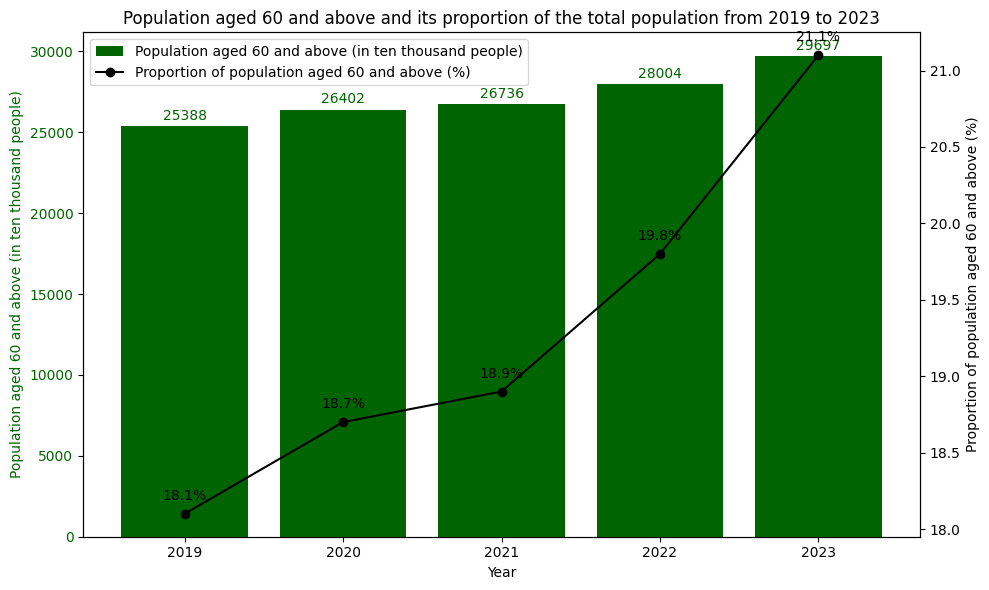

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Years
years = np.array([2019, 2020, 2021, 2022, 2023])
# Population aged 60 and above (in ten thousand people)
elderly_population = np.array([25388, 26402, 26736, 28004, 29697])
# Proportion of population aged 60 and above (%)
proportion = np.array([18.1, 18.7, 18.9, 19.8, 21.1])

# Create a figure and an axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Draw a bar chart (left - hand axis)
bars = ax1.bar(years, elderly_population, color='darkgreen', label='Population aged 60 and above (in ten thousand people)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Population aged 60 and above (in ten thousand people)', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')

# Add data labels above the bars
for bar, pop in zip(bars, elderly_population):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
             f'{pop}', ha='center', va='bottom', color='darkgreen')

# Create a right - hand axis for the line chart
ax2 = ax1.twinx()
line, = ax2.plot(years, proportion, marker='o', color='black', label='Proportion of population aged 60 and above (%)')
ax2.set_ylabel('Proportion of population aged 60 and above (%)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add data labels beside the data points of the line chart
for x, y in zip(years, proportion):
    ax2.annotate(f'{y}%', (x, y), textcoords='offset points',
                 xytext=(0,10), ha='center', color='black')

# Add a legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Set the x - axis ticks to years
ax1.set_xticks(years)

# Display the chart
plt.title('Population aged 60 and above and its proportion of the total population from 2019 to 2023')
plt.tight_layout()  # Adjust the layout to avoid content overlap
plt.show()

# 文件: chart_48_2.py

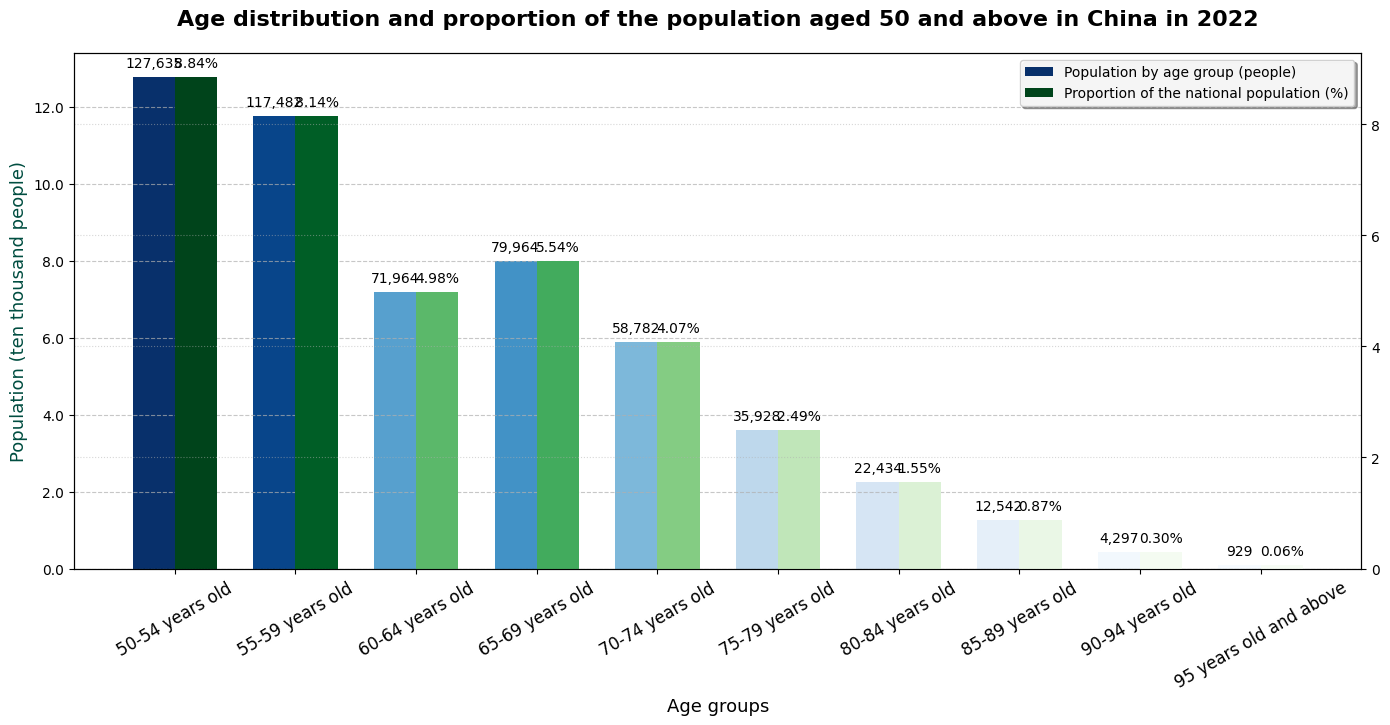

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Age groups
age_groups = [
    "50-54 years old", "55-59 years old", "60-64 years old", "65-69 years old", 
    "70-74 years old", "75-79 years old", "80-84 years old", "85-89 years old", 
    "90-94 years old", "95 years old and above"
]
# Population by age group (people)
population = [127635, 117482, 71964, 79964, 58782, 35928, 22434, 12542, 4297, 929]
# Proportion of the national population (%)
proportion = [8.84, 8.14, 4.98, 5.54, 4.07, 2.49, 1.55, 0.87, 0.30, 0.06]

x = np.arange(len(age_groups))  # x-axis coordinates
width = 0.35  # Bar width

# Create a canvas and primary and secondary axes
fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# Draw a bar chart of the population (dark blue gradient)
cmap1 = plt.cm.Blues
norm1 = plt.Normalize(min(population), max(population))
colors1 = [cmap1(norm1(value)) for value in population]
rects1 = ax1.bar(x - width/2, population, width, label='Population by age group (people)', color=colors1)

# Draw a bar chart of the proportion (dark green gradient)
cmap2 = plt.cm.Greens
norm2 = plt.Normalize(min(proportion), max(proportion))
colors2 = [cmap2(norm2(value)) for value in proportion]
rects2 = ax2.bar(x + width/2, proportion, width, label='Proportion of the national population (%)', color=colors2)

# Set axis labels and title
ax1.set_ylabel('Population (ten thousand people)', fontsize=13, color='#004D40')
ax1.set_xlabel('Age groups', fontsize=13)
ax1.set_title('Age distribution and proportion of the population aged 50 and above in China in 2022', fontsize=16, pad=20, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(age_groups, rotation=30, ha='center', fontsize=12)

# Set the y-axis format
def thousands_formatter(x, pos):
    return f'{x/10000:.1f}'
ax1.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# Add grid lines
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

# Add numerical labels to each bar (with thousands separators)
def add_labels(rects, ax, is_percent=False):
    for rect in rects:
        height = rect.get_height()
        if is_percent:
            label = f'{height:.2f}%'
        else:
            label = f'{height:,}'
        ax.annotate(label,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Vertical distance of the label from the bar
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10)

add_labels(rects1, ax1)
add_labels(rects2, ax2, is_percent=True)

# Beautify the legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True, framealpha=0.9, shadow=True)

# Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave space at the bottom and top
plt.show()

# 文件: chart_48_3.py

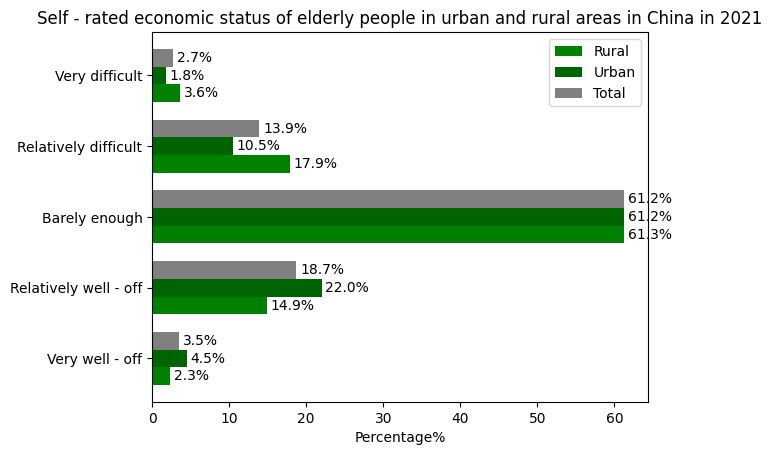

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Categories
categories = ['Very well - off', 'Relatively well - off', 'Barely enough', 'Relatively difficult', 'Very difficult']
# Rural data
rural = [2.3, 14.9, 61.3, 17.9, 3.6]
# Urban data
urban = [4.5, 22.0, 61.2, 10.5, 1.8]
# Total data
total = [3.5, 18.7, 61.2, 13.9, 2.7]

x = np.arange(len(categories))  # x-axis position
width = 0.25  # Width of each bar

fig, ax = plt.subplots()
# Draw bars for rural, urban, and total
rects1 = ax.barh(x - width, rural, width, label='Rural', color='green')
rects2 = ax.barh(x, urban, width, label='Urban', color='darkgreen')
rects3 = ax.barh(x + width, total, width, label='Total', color='gray')

# Add labels, title, etc.
ax.set_yticks(x)
ax.set_yticklabels(categories)
ax.set_xlabel('Percentage%')
ax.set_title('Self - rated economic status of elderly people in urban and rural areas in China in 2021')
ax.legend()

# Display values on the bars
def label_bars(rects):
    for rect in rects:
        length = rect.get_width()
        ax.text(length + 0.5, rect.get_y() + rect.get_height() / 2, f'{length}%', va='center')

label_bars(rects1)
label_bars(rects2)
label_bars(rects3)

plt.show()